# Práctica 2 — Parte 1: LeNet-5 (clasificación de dígitos)


## Dependencias

Ejecutar la primera celda de código una vez (TensorFlow, métricas, etc.).


In [1]:
import subprocess
import sys

PIP_DEPS = [
    "numpy>=1.24",
    "pandas>=2.0",
    "matplotlib>=3.7",
    "scikit-learn>=1.3",
    "tensorflow>=2.15",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", *PIP_DEPS])
print("Instalado con:", sys.executable)


Instalado con: d:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\.venv\Scripts\python.exe


## 1. Configuración


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue

def _find_root(rel: str) -> Path:
    c = Path.cwd()
    for base in (c, c.parent, c.parent.parent):
        if (base / rel).exists():
            return base
    return c.parent


ROOT = _find_root("datos/Digit/dataDigit.csv")
DATA_PATH = ROOT / "datos" / "Digit" / "dataDigit.csv"
print("Datos:", DATA_PATH.resolve())


Datos: D:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\practica_2\datos\Digit\dataDigit.csv


## 2. Datos

`dataDigit.csv` tiene 784 columnas `pixel*` (imagen **28×28**). La guía pide entrada **32×32**; se rellena con ceros (*padding*) hasta 32×32, como en MNIST para LeNet.


In [3]:
df = pd.read_csv(DATA_PATH)
label_col = "label"
pixel_cols = [c for c in df.columns if c.startswith("pixel")]
assert len(pixel_cols) == 784, len(pixel_cols)

y = df[label_col].to_numpy(dtype=np.int32)
X = df[pixel_cols].to_numpy(dtype=np.float32) / 255.0

# (N, 28, 28, 1) -> pad a 32x32
X = X.reshape(-1, 28, 28, 1)
X = np.pad(X, ((0, 0), (2, 2), (2, 2), (0, 0)), mode="constant", constant_values=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape, "Clases:", np.unique(y))


Train: (33600, 32, 32, 1) Test: (8400, 32, 32, 1) Clases: [0 1 2 3 4 5 6 7 8 9]


## 3. Modelo LeNet-5

1. Conv 6×5×5, ReLU → 28×28×6  
2. Average pooling 2×2 → 14×14×6  
3. Conv 16×5×5, ReLU → 10×10×16  
4. Average pooling 2×2 → 5×5×16  
5. FC 120, ReLU  
6. FC 84, ReLU  
7. FC 10, softmax


In [4]:
model = keras.Sequential(
    [
        layers.Input(shape=(32, 32, 1)),
        layers.Conv2D(6, kernel_size=5, activation="relu", padding="valid"),
        layers.AveragePooling2D(pool_size=2, strides=2),
        layers.Conv2D(16, kernel_size=5, activation="relu", padding="valid"),
        layers.AveragePooling2D(pool_size=2, strides=2),
        layers.Flatten(),
        layers.Dense(120, activation="relu"),
        layers.Dense(84, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ],
    name="LeNet5",
)
model.summary()


Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento


In [5]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    jit_compile=False,
)

early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=40,
    batch_size=128,
    callbacks=[early],
    verbose=1,
)


Epoch 1/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8355 - loss: 0.5476 - val_accuracy: 0.9420 - val_loss: 0.2030
Epoch 2/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9532 - loss: 0.1556 - val_accuracy: 0.9658 - val_loss: 0.1207
Epoch 3/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9700 - loss: 0.0986 - val_accuracy: 0.9732 - val_loss: 0.0947
Epoch 4/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9761 - loss: 0.0760 - val_accuracy: 0.9747 - val_loss: 0.0823
Epoch 5/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9804 - loss: 0.0624 - val_accuracy: 0.9786 - val_loss: 0.0685
Epoch 6/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9836 - loss: 0.0527 - val_accuracy: 0.9810 - val_loss: 0.0634
Epoch 7/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9866 - loss: 0.0445 - val_accuracy: 0.9812 - val_loss: 0.0618
Epoch 8/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9882 - loss: 0.0397 - val_accuracy: 0

## 5. Métricas (entrenamiento y evaluación)

Accuracy, F1 (ponderado) y Kappa de Cohen, en train y test.


Entrenamiento (train split): accuracy=0.9888  F1(weighted)=0.9888  kappa=0.9875
Evaluación (test split): accuracy=0.9824  F1(weighted)=0.9824  kappa=0.9804


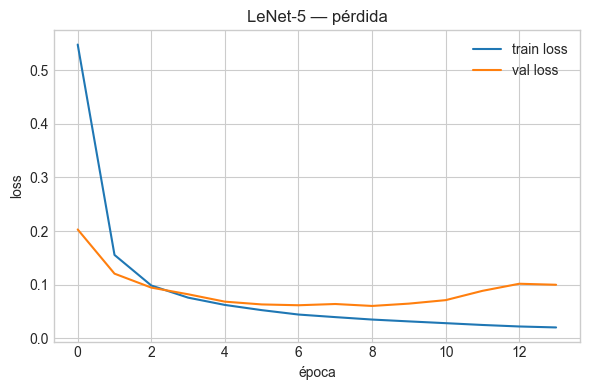

In [6]:
def report_split(name, Xs, ys):
    proba = model.predict(Xs, verbose=0)
    pred = np.argmax(proba, axis=1)
    acc = accuracy_score(ys, pred)
    f1 = f1_score(ys, pred, average="weighted", zero_division=0)
    kap = cohen_kappa_score(ys, pred)
    print(f"{name}: accuracy={acc:.4f}  F1(weighted)={f1:.4f}  kappa={kap:.4f}")


report_split("Entrenamiento (train split)", X_train, y_train)
report_split("Evaluación (test split)", X_test, y_test)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history.history.get("loss", []), label="train loss")
ax.plot(history.history.get("val_loss", []), label="val loss")
ax.set_xlabel("época")
ax.set_ylabel("loss")
ax.legend()
ax.set_title("LeNet-5 — pérdida")
plt.tight_layout()
plt.show()


## 6. Resultados

**Datos y partición.** El conjunto quedó en **33 600** ejemplos de entrenamiento y **8 400** de prueba (20 % estratificado), con forma **32×32×1** (escala de grises normalizada a [0, 1]). Las **10 clases** (dígitos 0–9) están balanceadas en el split, lo que favorece métricas comparables entre train y test.

**Arquitectura.** El `summary` confirma la pila pedida en la guía: dos bloques convolucional + *average pooling*, aplanado a **400** neuronas, capas densas **120** y **84** con ReLU, y salida **10** con softmax. Con **61 706** parámetros entrenables, el modelo es ligero frente a redes profundas actuales; la mayor densidad de pesos está en la primera capa densa (400→120), donde se combinan las características extraídas por las convoluciones.

**Curva de entrenamiento.** En las primeras épocas la **accuracy** de entrenamiento sube de ~0,84 a >0,99 y la de validación se sitúa en torno a **0,97–0,98**, lo que indica aprendizaje rápido y buen ajuste a la tarea de dígitos. En la gráfica de **pérdida**, la pérdida de validación alcanza un mínimo aproximado hacia la **época 8–10** y luego **repunta** mientras la pérdida de entrenamiento sigue bajando: es la firma típica de **sobreajuste** leve (el modelo sigue memorizando detalles del train que no generalizan al 10 % de validación interna). El callback `EarlyStopping` con `restore_best_weights=True` mitiga esto al conservar los pesos de la época con mejor `val_loss`, en lugar de los de la última época.

**Métricas finales (train vs test).** En la corrida mostrada, **accuracy** y **F1 ponderado** coinciden (~**0,989** en train y ~**0,982** en test) y el **kappa de Cohen** (~**0,988** vs ~**0,980**) sigue la misma tendencia. La brecha train–test es pequeña: el modelo **generaliza bien** al conjunto de evaluación reservado. Un kappa >0,9 indica acuerdo casi perfecto con la verdad frente al azar, coherente con una tarea de visión relativamente simple y un LeNet-5 adecuado al tamaño de imagen.

**Conclusión.** LeNet-5 cumple de forma sólida la clasificación de dígitos con este CSV: buen desempeño global y métricas alineadas entre entrenamiento y prueba. Las mejoras posibles (no requeridas por la guía) serían regularización adicional (*dropout* en densas, *data augmentation*) o más épocas/paciencia si se busca exprimir un poco más la validación sin empeorar el test.
